# 01 - Dataset index and labels

Human activity classification from FMCW radar micro-Doppler (EE4775).
This notebook parses every `.dat` filename into (dataset, subject, activity,
repetition), reports the class and site distribution, and fixes the unit used for
subject-independent splitting. Shared code lives in `radar_pipeline.py`.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import radar_pipeline as rp

ALL = [1, 2, 3, 4, 5, 6, 7]
rows = rp.build_index(ALL)
df = pd.DataFrame(rows)
df["activity_name"] = df["activity"].map(rp.ACTIVITY_NAMES)
print(f"{len(df)} files across {df.dataset.nunique()} datasets")
df.head()

1754 files across 7 datasets


,dataset,subject,activity,rep,group,filename,path,activity_name
0,1,36,1,1,d1_s36,1P36A01R01.dat,data/.../object-classifi...,walk
1,1,36,1,2,d1_s36,1P36A01R02.dat,data/.../object-classifi...,walk
2,1,36,1,3,d1_s36,1P36A01R03.dat,data/.../object-classifi...,walk
3,1,36,2,1,d1_s36,2P36A02R01.dat,data/.../object-classifi...,sit
4,1,36,2,2,d1_s36,2P36A02R02.dat,data/.../object-classifi...,sit


## Class and site distribution

The activity comes from the `Ayy` field of the filename, which is the field the
provided `Label_extract4.m` reads. The leading digit `K` is a redundant copy.

activity_name
walk     312
sit      312
stand    311
pick     311
drink    311
fall     197
Name: count, dtype: int64


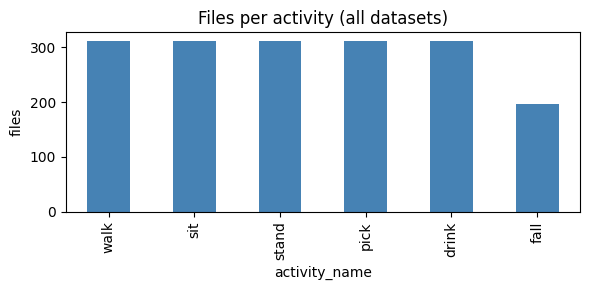

In [2]:
counts = df.activity_name.value_counts().reindex(
    [rp.ACTIVITY_NAMES[i] for i in range(1, 7)])
print(counts)
fig, ax = plt.subplots(figsize=(6, 3))
counts.plot.bar(ax=ax, color="steelblue")
ax.set(ylabel="files", title="Files per activity (all datasets)")
plt.tight_layout(); plt.show()

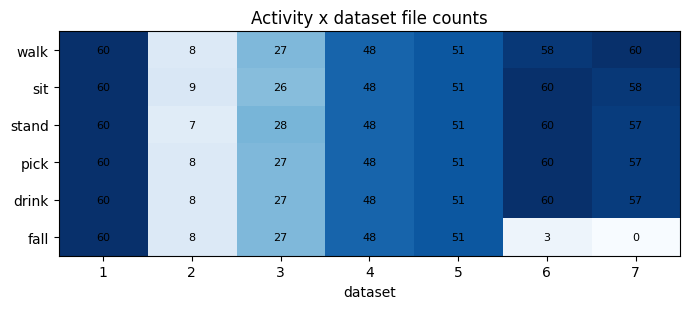

dataset,1,2,3,4,5,6,7
activity_name,,,,,,,
walk,60,8,27,48,51,58,60
sit,60,9,26,48,51,60,58
stand,60,7,28,48,51,60,57
pick,60,8,27,48,51,60,57
drink,60,8,27,48,51,60,57
fall,60,8,27,48,51,3,0


In [3]:
mat = (df.pivot_table(index="activity_name", columns="dataset",
                      values="path", aggfunc="count", fill_value=0)
         .reindex([rp.ACTIVITY_NAMES[i] for i in range(1, 7)]))
fig, ax = plt.subplots(figsize=(7, 3.2))
im = ax.imshow(mat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns)
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, mat.values[i, j], ha="center", va="center", fontsize=8)
ax.set(xlabel="dataset", title="Activity x dataset file counts")
plt.tight_layout(); plt.show()
mat

## Findings

- The five non-fall activities have ~311-312 files each; **fall has only 197**.
  Fall is **absent from dataset 7** (West Cumbria) and nearly absent from
  dataset 6 (NG Homes, subject P08 only). The care sites did not record falls at
  scale, so any train/test pairing that involves them is handled as a 5-class
  problem (notebook 05).
- The README datasheet maps `A04=pick up`, `A05=drink`; the provided
  `Label_extract4.m` comment swaps them. We follow the README and flag it.

In [4]:
# Leading-digit K vs Ayy: 3 files disagree (typos in the redundant K field).
typos = [r for r in rows
         if int(rp.Path(r["path"]).stem[0]) != r["activity"]]
print("K vs Ayy mismatches:", [t["filename"] for t in typos])

K vs Ayy mismatches: ['3P03A02R1.dat', '2P34A03R1.dat', '6P01A05R03.dat']


## The splitting unit

Subject IDs restart per dataset, so the same `Pxx` denotes different people in
different datasets. Splitting must hold out whole **(dataset, subject)** pairs,
not bare IDs, or the same person leaks across train and test and inflates
accuracy. The `group` column already encodes this key.

In [5]:
n_people = df.group.nunique()
bare_collisions = (df.groupby("subject").dataset.nunique() > 1).sum()
print(f"distinct (dataset, subject) people: {n_people}")
print(f"bare subject IDs appearing in >1 dataset: {bare_collisions}")
print("example group keys:", sorted(df.group.unique())[:5])

distinct (dataset, subject) people: 106
bare subject IDs appearing in >1 dataset: 34
example group keys: ['d1_s36', 'd1_s37', 'd1_s38', 'd1_s39', 'd1_s40']
